# 18_E10 - Axial T2 final training clean

Fase 2. Entrenamiento final limpio para el módulo axial T2 usando el split curado generado en E9.

Objetivo: reentrenar de forma reproducible, sin multiprocessing, y reportar métricas con y sin la clase minoritaria `raw_0`.


In [3]:
%pip install pydicom scikit-image torch


In [5]:
import json, random, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pydicom, torch
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from skimage.transform import resize
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
PFI_ROOT=Path('/content/drive/MyDrive/PFI_MVP')
E9_ROOT=PFI_ROOT/'results'/'E9_alkafri_axial_t2_final_labels_baseline'
E10_ROOT=PFI_ROOT/'results'/'E10_axial_t2_final_training_clean'
FIGURES_ROOT=PFI_ROOT/'figures'; MODELS_ROOT=PFI_ROOT/'models'; DOCS_ROOT=PFI_ROOT/'docs'
for p in [E10_ROOT,FIGURES_ROOT,MODELS_ROOT,DOCS_ROOT]: p.mkdir(parents=True, exist_ok=True)
SPLIT_PATH=E9_ROOT/'E9_t2_final_labels_curated_split.csv'
assert SPLIT_PATH.exists(), 'Falta el split E9. Ejecutar primero notebook 17_E9.'
IMG_SIZE=256; NUM_CLASSES=6; BATCH_SIZE=8; EPOCHS=15; LR=1e-3; BASE=16
RAW_VALUES=np.array([0,50,100,150,200,250],dtype=np.int16)
RAW_TO_CLASS={250:0,0:1,50:2,100:3,150:4,200:5}
CLASS_NAMES={0:'background_250',1:'raw_0',2:'raw_50',3:'raw_100',4:'raw_150',5:'raw_200'}
print('SPLIT_PATH:',SPLIT_PATH)
print('cuda:',torch.cuda.is_available())


Mounted at /content/drive
SPLIT_PATH: /content/drive/MyDrive/PFI_MVP/results/E9_alkafri_axial_t2_final_labels_baseline/E9_t2_final_labels_curated_split.csv
cuda: False


In [7]:
def read_img(p): return pydicom.dcmread(str(p),force=True).pixel_array.astype(np.float32)
def norm_img(x):
    p1,p99=np.percentile(x,[1,99])
    return np.zeros_like(x,dtype=np.float32) if p99<=p1 else ((np.clip(x,p1,p99)-p1)/(p99-p1+1e-8)).astype(np.float32)
def read_label(p):
    a=np.asarray(Image.open(p)); a=a[...,0] if a.ndim==3 else a; a=a.astype(np.int16); flat=a.reshape(-1)
    snap=RAW_VALUES[np.abs(flat[:,None]-RAW_VALUES[None,:]).argmin(axis=1)].reshape(a.shape)
    y=np.zeros_like(snap,dtype=np.uint8)
    for rv,c in RAW_TO_CLASS.items(): y[snap==rv]=c
    return y
def rimg(x): return resize(x,(IMG_SIZE,IMG_SIZE),order=1,preserve_range=True,anti_aliasing=True).astype(np.float32)
def rlbl(y): return resize(y.astype(np.float32),(IMG_SIZE,IMG_SIZE),order=0,preserve_range=True,anti_aliasing=False).astype(np.uint8)
class DS(Dataset):
    def __init__(self,df): self.df=df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]; x=rimg(norm_img(read_img(r.image_file_path))); y=rlbl(read_label(r.final_label_file_path))
        return torch.from_numpy(x[None]).float(), torch.from_numpy(y).long()
df=pd.read_csv(SPLIT_PATH)
df['case_id_norm']=df.case_id_norm.astype(str).str.zfill(4)
train_df=df[df.split.eq('train')]; val_df=df[df.split.eq('val')]; test_df=df[df.split.eq('test')]
loaders={
 'train':DataLoader(DS(train_df),batch_size=BATCH_SIZE,shuffle=True,num_workers=0,pin_memory=False),
 'val':DataLoader(DS(val_df),batch_size=BATCH_SIZE,shuffle=False,num_workers=0,pin_memory=False),
 'test':DataLoader(DS(test_df),batch_size=BATCH_SIZE,shuffle=False,num_workers=0,pin_memory=False)}
display(df.groupby('split').agg(n=('case_id_norm','size'),cases=('case_id_norm','nunique')).reset_index())


,split,n,cases
0,test,102,29
1,train,427,128
2,val,81,27


In [8]:
class DC(nn.Module):
    def __init__(self,a,b): super().__init__(); self.net=nn.Sequential(nn.Conv2d(a,b,3,padding=1),nn.BatchNorm2d(b),nn.ReLU(True),nn.Conv2d(b,b,3,padding=1),nn.BatchNorm2d(b),nn.ReLU(True))
    def forward(self,x): return self.net(x)
class UNet(nn.Module):
    def __init__(self):
        super().__init__(); b=BASE
        self.e1=DC(1,b); self.e2=DC(b,b*2); self.e3=DC(b*2,b*4); self.pool=nn.MaxPool2d(2); self.mid=DC(b*4,b*8)
        self.u3=nn.ConvTranspose2d(b*8,b*4,2,2); self.d3=DC(b*8,b*4); self.u2=nn.ConvTranspose2d(b*4,b*2,2,2); self.d2=DC(b*4,b*2); self.u1=nn.ConvTranspose2d(b*2,b,2,2); self.d1=DC(b*2,b); self.out=nn.Conv2d(b,NUM_CLASSES,1)
    def forward(self,x):
        e1=self.e1(x); e2=self.e2(self.pool(e1)); e3=self.e3(self.pool(e2)); m=self.mid(self.pool(e3))
        x=self.d3(torch.cat([self.u3(m),e3],1)); x=self.d2(torch.cat([self.u2(x),e2],1)); x=self.d1(torch.cat([self.u1(x),e1],1)); return self.out(x)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'); model=UNet().to(device)
opt=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=1e-4)
def dice_loss(logits,y,eps=1e-6):
    p=torch.softmax(logits,1); oh=F.one_hot(y,NUM_CLASSES).permute(0,3,1,2).float(); inter=(p*oh).sum((0,2,3)); den=p.sum((0,2,3))+oh.sum((0,2,3)); return 1-((2*inter+eps)/(den+eps))[1:].mean()
def loss_fn(logits,y): return F.cross_entropy(logits,y)+dice_loss(logits,y)
@torch.no_grad()
def evaluate(loader):
    model.eval(); inter=torch.zeros(NUM_CLASSES,device=device); ps=torch.zeros(NUM_CLASSES,device=device); gs=torch.zeros(NUM_CLASSES,device=device); losses=[]
    for x,y in loader:
        x=x.to(device); y=y.to(device); z=model(x); losses.append(float(loss_fn(z,y).cpu())); pred=z.argmax(1)
        for c in range(NUM_CLASSES):
            p=pred==c; g=y==c; inter[c]+=(p&g).sum(); ps[c]+=p.sum(); gs[c]+=g.sum()
    dice=(2*inter)/(ps+gs+1e-7); iou=inter/(ps+gs-inter+1e-7)
    all_fg=[1,2,3,4,5]; useful=[2,3,4,5]
    return {'loss':float(np.mean(losses)),'dice_macro_no_bg':float(dice[all_fg].mean().cpu()),'iou_macro_no_bg':float(iou[all_fg].mean().cpu()),'dice_macro_excluding_raw0':float(dice[useful].mean().cpu()),'iou_macro_excluding_raw0':float(iou[useful].mean().cpu()),'dice_by_class':{CLASS_NAMES[i]:float(dice[i].cpu()) for i in range(NUM_CLASSES)},'iou_by_class':{CLASS_NAMES[i]:float(iou[i].cpu()) for i in range(NUM_CLASSES)}}
print('device:',device,'train/val/test:',len(train_df),len(val_df),len(test_df))


device: cpu train/val/test: 427 81 102


E10 epoch 01/15:   0%|          | 0/54 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 2.1512051577921265, 'val_loss': 1.8301272609017112, 'val_dice_macro_no_bg': 0.2008383721113205, 'val_dice_macro_excluding_raw0': 0.25104793906211853}
nuevo best useful dice: 0.25104793906211853


E10 epoch 02/15:   0%|          | 0/54 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 1.4908787497767695, 'val_loss': 1.2786999073895542, 'val_dice_macro_no_bg': 0.4410429000854492, 'val_dice_macro_excluding_raw0': 0.5513036251068115}
nuevo best useful dice: 0.5513036251068115


E10 epoch 03/15:   0%|          | 0/54 [00:00<?, ?it/s]

...

E10 epoch 14/15:   0%|          | 0/54 [00:00<?, ?it/s]

{'epoch': 14, 'train_loss': 0.3676756979138763, 'val_loss': 0.34426678852601483, 'val_dice_macro_no_bg': 0.7053713798522949, 'val_dice_macro_excluding_raw0': 0.8817142248153687}
nuevo best useful dice: 0.8817142248153687


E10 epoch 15/15:   0%|          | 0/54 [00:00<?, ?it/s]

{'epoch': 15, 'train_loss': 0.36436244735011347, 'val_loss': 0.3520394563674927, 'val_dice_macro_no_bg': 0.7206857800483704, 'val_dice_macro_excluding_raw0': 0.8778865337371826}


,epoch,train_loss,val_loss,val_dice_macro_no_bg,val_dice_macro_excluding_raw0
10,11,0.389081,0.370612,0.692518,0.865647
11,12,0.384274,0.432228,0.658787,0.807728
12,13,0.381936,0.379408,0.692886,0.863196
13,14,0.367676,0.344267,0.705371,0.881714
14,15,0.364362,0.352039,0.720686,0.877887


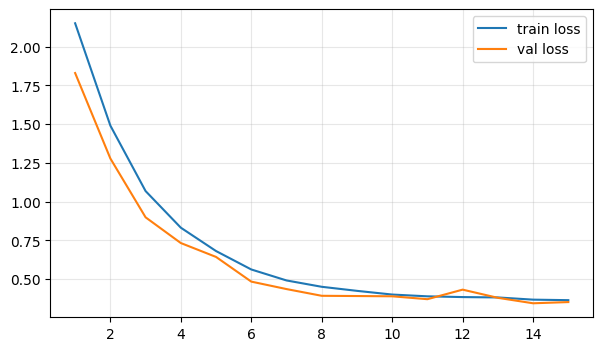

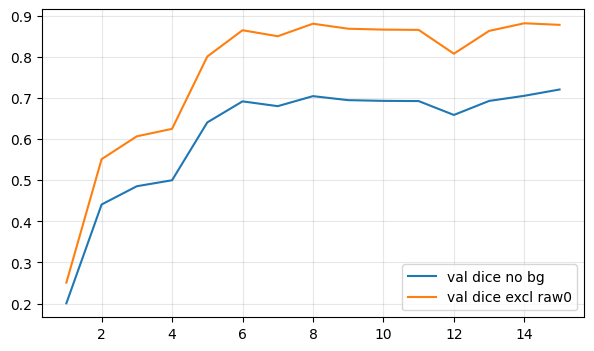

In [9]:
hist=[]; best=-1; best_state=None; best_path=MODELS_ROOT/'E10_axial_t2_final_training_clean_best.pt'
for ep in range(1,EPOCHS+1):
    model.train(); tr=[]
    for x,y in tqdm(loaders['train'],desc=f'E10 epoch {ep:02d}/{EPOCHS}',leave=False):
        x=x.to(device); y=y.to(device); opt.zero_grad(set_to_none=True); loss=loss_fn(model(x),y); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step(); tr.append(float(loss.detach().cpu()))
    vm=evaluate(loaders['val']); row={'epoch':ep,'train_loss':float(np.mean(tr)),'val_loss':vm['loss'],'val_dice_macro_no_bg':vm['dice_macro_no_bg'],'val_dice_macro_excluding_raw0':vm['dice_macro_excluding_raw0']}
    hist.append(row); print(row)
    if vm['dice_macro_excluding_raw0']>best:
        best=vm['dice_macro_excluding_raw0']; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}; torch.save(best_state,best_path); print('nuevo best useful dice:',best)
hist=pd.DataFrame(hist); hist.to_csv(E10_ROOT/'E10_training_history.csv',index=False); display(hist.tail())
plt.figure(figsize=(7,4)); plt.plot(hist.epoch,hist.train_loss,label='train loss'); plt.plot(hist.epoch,hist.val_loss,label='val loss'); plt.legend(); plt.grid(alpha=.3); plt.savefig(FIGURES_ROOT/'E10_axial_t2_training_loss.png',dpi=150,bbox_inches='tight'); plt.show()
plt.figure(figsize=(7,4)); plt.plot(hist.epoch,hist.val_dice_macro_no_bg,label='val dice no bg'); plt.plot(hist.epoch,hist.val_dice_macro_excluding_raw0,label='val dice excl raw0'); plt.legend(); plt.grid(alpha=.3); plt.savefig(FIGURES_ROOT/'E10_axial_t2_val_dice.png',dpi=150,bbox_inches='tight'); plt.show()


In [10]:
model.load_state_dict(best_state if best_state is not None else torch.load(best_path,map_location='cpu')); model.to(device)
val_metrics=evaluate(loaders['val']); test_metrics=evaluate(loaders['test'])
print('VAL:',json.dumps(val_metrics,indent=2,ensure_ascii=False)); print('TEST:',json.dumps(test_metrics,indent=2,ensure_ascii=False))
(E10_ROOT/'E10_val_metrics.json').write_text(json.dumps(val_metrics,indent=2,ensure_ascii=False),encoding='utf-8'); (E10_ROOT/'E10_test_metrics.json').write_text(json.dumps(test_metrics,indent=2,ensure_ascii=False),encoding='utf-8')
report={'notebook':'18_E10_axial_t2_final_training_clean','strategy':'clean final T2-only training using E9 curated split','curated_candidates':int(len(df)),'split_counts':df.groupby('split').size().to_dict(),'epochs':EPOCHS,'best_model_path':str(best_path),'best_val_dice_macro_excluding_raw0':float(best),'val_metrics':val_metrics,'test_metrics':test_metrics,'decision':'final_axial_t2_model_trained'}
rp=E10_ROOT/'E10_axial_t2_final_training_clean_report.json'; rp.write_text(json.dumps(report,indent=2,ensure_ascii=False),encoding='utf-8')
(DOCS_ROOT/'E10_axial_t2_final_training_clean_conclusion.md').write_text('# E10 axial T2 final training clean\n\n'+json.dumps(report,indent=2,ensure_ascii=False),encoding='utf-8')
print('Reporte:',rp); print(json.dumps(report,indent=2,ensure_ascii=False))


VAL: {
  "loss": 0.34426678852601483,
  "dice_macro_no_bg": 0.7053713798522949,
  "iou_macro_no_bg": 0.6363672614097595,
  "dice_macro_excluding_raw0": 0.8817142248153687,
  "iou_macro_excluding_raw0": 0.7954590320587158,
  "dice_by_class": {
    "background_250": 0.9950625896453857,
    "raw_0": 0.0,
    "raw_50": 0.9667284488677979,
    "raw_100": 0.9084652662277222,
    "raw_150": 0.8800813555717468,
    "raw_200": 0.771581768989563
  },
  "iou_by_class": {
    "background_250": 0.9901736378669739,
    "raw_0": 0.0,
    "raw_50": 0.9355996251106262,
    "raw_100": 0.832282543182373,
    "raw_150": 0.7858440279960632,
    "raw_200": 0.6281099915504456
  }
}
TEST: {
  "loss": 0.4142925922687237,
  "dice_macro_no_bg": 0.6586844325065613,
  "iou_macro_no_bg": 0.5627642869949341,
  "dice_macro_excluding_raw0": 0.8167458176612854,
  "iou_macro_excluding_raw0": 0.7001062631607056,
  "dice_by_class": {
    "background_250": 0.9929601550102234,
    "raw_0": 0.026438886299729347,
    "raw_50"